# RAG Chunking Strategies — Applied to Week 8 PDF

**Source:** `Week7_Wed_17_Sep.pdf`  
**Objective:** extract the PDF, apply fixed-size, sentence, paragraph, recursive, and optional semantic chunking, compare the chunk counts and chunk lengths, visualize the results, and record an engineering recommendation.

> Keep `Week7_Wed_17_Sep.pdf` and `rag_chunking_strategies_updated.py` in the same directory as this notebook. The notebook keeps chunking and indexing inside Python; the LLM does not need to see or run the chunking algorithm.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import pymupdf  

from rag_chunking_strategies_updated import (
    fixed_size_chunk,
    sentence_chunk,
    paragraph_chunk,
    recursive_chunk,
    SemanticChunker,
)

PDF_PATH = Path("Week7_Wed_17_Sep.pdf")
assert PDF_PATH.exists(), (
    f"Could not find {PDF_PATH}. Put the PDF beside this notebook "
    "or update PDF_PATH to its location."
)

print("PDF:", PDF_PATH.resolve())


PDF: /home/as/Downloads/Repos/DailyTask/Task31/Week7_Wed_17_Sep.pdf


## 2. Extract text while preserving page provenance

We extract each page separately. This keeps page numbers accurate and prevents a chunk from silently crossing page boundaries. For complex layouts, scanned pages, or tables, use OCR/table extraction as a separate preprocessing step.


In [2]:
pdf = pymupdf.open(PDF_PATH)

page_records = []
for page_index, page in enumerate(pdf):
    page_text = page.get_text("text").strip()
    if page_text:
        page_records.append({
            "page": page_index + 1,
            "text": page_text,
        })

print(f"Pages in PDF: {len(pdf)}")
print(f"Pages containing extractable text: {len(page_records)}")
print(f"Total extracted characters: {sum(len(r['text']) for r in page_records):,}")
display(pd.DataFrame([
    {"page": r["page"], "characters": len(r["text"])}
    for r in page_records
]))


Pages in PDF: 6
Pages containing extractable text: 6
Total extracted characters: 10,958


,page,characters
0,1,2564
1,2,1933
2,3,1831
3,4,2160
4,5,2456
5,6,14


## Using Langchain

### Fixed-Size Chunking

In [3]:
from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
chunks = []
for record in page_records:
    page_chunks = splitter.split_text(record["text"])
    for chunk in page_chunks:
        chunks.append(
            {
                "page":record["page"],
                "text": chunk
            }
        )
print("Fixed Size Chunks:", len(chunks))
print(chunks[0])


Fixed Size Chunks: 6
{'page': 1, 'text': "Status \nName: Timothious Gill \nDesignation : AI/ML Intern \nGitLink: Week 7: Wed \nDate: 17/09/2026 \nSummary  \nToday I continued working on Task 29, which focuses on building a FastAPI service for interacting \nwith both local and hosted Large Language Models (LLMs). The main focus was on improving the \nservice structure, separating configuration from application logic, using a shared model-calling \nfunction, integrating OpenAI-compatible clients, and making the service easier to configure and \nevaluate. \nA major part of today's work involved understanding the architecture of the FastAPI service. Both \n/chat/local and /chat/hosted endpoints follow the same request and response contract \nwhile using the shared ask_model() function for model inference. This helped reinforce the \nconcept of separating the API layer from the underlying model provider and inference logic. \nI also reviewed how the application selects between local and hos

### Sentence Chunking

In [4]:
from langchain_text_splitters import NLTKTextSplitter

splitter = NLTKTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

sentence_chunks = []

for record in page_records:
    page_chunks = splitter.split_text(record["text"])

    for chunk in page_chunks:
        sentence_chunks.append({
            "page": record["page"],
            "text": chunk
        })

print("Sentence Chunks:", len(sentence_chunks))
print(chunks[0])

Created a chunk of size 404, which is longer than the specified 300


Sentence Chunks: 50
{'page': 1, 'text': "Status \nName: Timothious Gill \nDesignation : AI/ML Intern \nGitLink: Week 7: Wed \nDate: 17/09/2026 \nSummary  \nToday I continued working on Task 29, which focuses on building a FastAPI service for interacting \nwith both local and hosted Large Language Models (LLMs). The main focus was on improving the \nservice structure, separating configuration from application logic, using a shared model-calling \nfunction, integrating OpenAI-compatible clients, and making the service easier to configure and \nevaluate. \nA major part of today's work involved understanding the architecture of the FastAPI service. Both \n/chat/local and /chat/hosted endpoints follow the same request and response contract \nwhile using the shared ask_model() function for model inference. This helped reinforce the \nconcept of separating the API layer from the underlying model provider and inference logic. \nI also reviewed how the application selects between local and host

### Paragraph Chunking

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
paragraph_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""]
)

paragraph_chunks = []

for record in page_records:
    page_chunks = paragraph_splitter.split_text(record["text"])

    for chunk in page_chunks:
        paragraph_chunks.append({
            "page": record["page"],
            "text": chunk
        })

print("Paragraph Chunks:", len(paragraph_chunks))
print(paragraph_chunks[0])

Paragraph Chunks: 45
{'page': 1, 'text': 'Status \nName: Timothious Gill \nDesignation : AI/ML Intern \nGitLink: Week 7: Wed \nDate: 17/09/2026 \nSummary  \nToday I continued working on Task 29, which focuses on building a FastAPI service for interacting'}


### Semantic Chunking

In [6]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

semantic_splitter = SemanticChunker(
    embeddings=embedding_model,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=95
)

semantic_chunks = []

for record in page_records:
    page_chunks = semantic_splitter.split_text(
        record["text"]
    )

    for chunk in page_chunks:
        semantic_chunks.append({
            "page": record["page"],
            "text": chunk
        })

print("Semantic Chunks:", len(semantic_chunks))
print(semantic_chunks[0])

/tmp/ipykernel_31166/2175643453.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.text_splitter import SemanticChunker


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Semantic Chunks: 12
{'page': 1, 'text': "Status \nName: Timothious Gill \nDesignation : AI/ML Intern \nGitLink: Week 7: Wed \nDate: 17/09/2026 \nSummary  \nToday I continued working on Task 29, which focuses on building a FastAPI service for interacting \nwith both local and hosted Large Language Models (LLMs). The main focus was on improving the \nservice structure, separating configuration from application logic, using a shared model-calling \nfunction, integrating OpenAI-compatible clients, and making the service easier to configure and \nevaluate. A major part of today's work involved understanding the architecture of the FastAPI service. Both \n/chat/local and /chat/hosted endpoints follow the same request and response contract \nwhile using the shared ask_model() function for model inference. This helped reinforce the \nconcept of separating the API layer from the underlying model provider and inference logic. I also reviewed how the application selects between local and hosted i

In [7]:

semantic_df = pd.DataFrame(semantic_chunks)

semantic_df["chunk_length"] = (
    semantic_df["text"].str.len()
)

print(semantic_df["chunk_length"].describe())

print("Total chunks:", len(semantic_chunks))

print(
    "Largest chunk:",
    semantic_df["chunk_length"].max()
)

count      12.000000
mean      905.916667
std       698.678032
min        14.000000
25%       450.750000
50%       569.000000
75%      1301.250000
max      2165.000000
Name: chunk_length, dtype: float64
Total chunks: 12
Largest chunk: 2165


In [8]:
# First Five Chunks
for i, chunk in enumerate(semantic_chunks[:5]):
    print(f"\n--- Semantic Chunk {i + 1} ---")
    print("Page:", chunk["page"])
    print("Length:", len(chunk["text"]))
    print(chunk["text"])


--- Semantic Chunk 1 ---
Page: 1
Length: 2016
Status 
Name: Timothious Gill 
Designation : AI/ML Intern 
GitLink: Week 7: Wed 
Date: 17/09/2026 
Summary  
Today I continued working on Task 29, which focuses on building a FastAPI service for interacting 
with both local and hosted Large Language Models (LLMs). The main focus was on improving the 
service structure, separating configuration from application logic, using a shared model-calling 
function, integrating OpenAI-compatible clients, and making the service easier to configure and 
evaluate. A major part of today's work involved understanding the architecture of the FastAPI service. Both 
/chat/local and /chat/hosted endpoints follow the same request and response contract 
while using the shared ask_model() function for model inference. This helped reinforce the 
concept of separating the API layer from the underlying model provider and inference logic. I also reviewed how the application selects between local and hosted inferenc

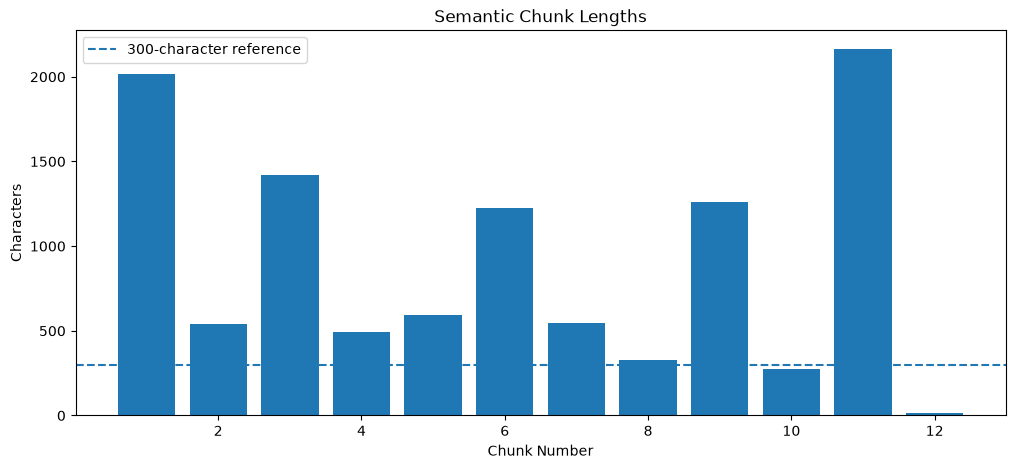

In [9]:

semantic_df = pd.DataFrame(semantic_chunks)

semantic_df["chunk_length"] = (
    semantic_df["text"].str.len()
)

plt.figure(figsize=(12, 5))

plt.bar(
    range(1, len(semantic_df) + 1),
    semantic_df["chunk_length"]
)

plt.axhline(
    y=300,
    linestyle="--",
    label="300-character reference"
)

plt.title("Semantic Chunk Lengths")
plt.xlabel("Chunk Number")
plt.ylabel("Characters")
plt.legend()
plt.show()

### Recursive Chunking

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

recursive_chunks = []

for record in page_records:
    page_chunks = recursive_splitter.split_text(
        record["text"]
    )

    for chunk in page_chunks:
        recursive_chunks.append({
            "page": record["page"],
            "text": chunk
        })

print("Recursive Chunks:", len(recursive_chunks))
print(recursive_chunks[0])

Recursive Chunks: 45
{'page': 1, 'text': 'Status \nName: Timothious Gill \nDesignation : AI/ML Intern \nGitLink: Week 7: Wed \nDate: 17/09/2026 \nSummary  \nToday I continued working on Task 29, which focuses on building a FastAPI service for interacting'}


In [11]:
recursive_df = pd.DataFrame(recursive_chunks)

recursive_df["chunk_length"] = (
    recursive_df["text"].str.len()
)

print(recursive_df["chunk_length"].describe())

print(
    "Chunks exceeding 300:",
    (recursive_df["chunk_length"] > 300).sum()
)

print(
    "Largest chunk:",
    recursive_df["chunk_length"].max()
)

count     45.000000
mean     252.155556
std       52.563795
min       14.000000
25%      240.000000
50%      271.000000
75%      281.000000
max      298.000000
Name: chunk_length, dtype: float64
Chunks exceeding 300: 0
Largest chunk: 298


In [12]:
# First Five Chunks
for i, chunk in enumerate(recursive_chunks[:5]):
    print(f"\n--- Recursive Chunk {i + 1} ---")
    print("Page:", chunk["page"])
    print("Length:", len(chunk["text"]))
    print(chunk["text"])


--- Recursive Chunk 1 ---
Page: 1
Length: 206
Status 
Name: Timothious Gill 
Designation : AI/ML Intern 
GitLink: Week 7: Wed 
Date: 17/09/2026 
Summary  
Today I continued working on Task 29, which focuses on building a FastAPI service for interacting

--- Recursive Chunk 2 ---
Page: 1
Length: 298
with both local and hosted Large Language Models (LLMs). The main focus was on improving the 
service structure, separating configuration from application logic, using a shared model-calling 
function, integrating OpenAI-compatible clients, and making the service easier to configure and 
evaluate.

--- Recursive Chunk 3 ---
Page: 1
Length: 286
evaluate. 
A major part of today's work involved understanding the architecture of the FastAPI service. Both 
/chat/local and /chat/hosted endpoints follow the same request and response contract 
while using the shared ask_model() function for model inference. This helped reinforce the

--- Recursive Chunk 4 ---
Page: 1
Length: 278
concept of separati

## Comparison

In [13]:
comparison = pd.DataFrame({
    "Strategy": [
        "Character",
        "Sentence",
        "Paragraph",
        "Semantic",
        "Recursive"
    ],
    "Chunks": [
        len(chunks),
        len(sentence_chunks),
        len(paragraph_chunks),
        len(semantic_chunks),
        len(recursive_chunks)
    ]
})

comparison

,Strategy,Chunks
0,Character,6
1,Sentence,50
2,Paragraph,45
3,Semantic,12
4,Recursive,45


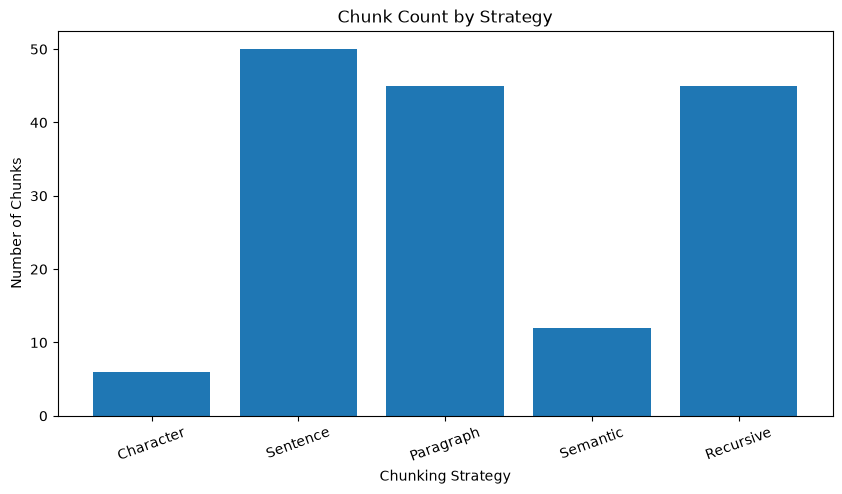

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Strategy"],
    comparison["Chunks"]
)

plt.title("Chunk Count by Strategy")
plt.xlabel("Chunking Strategy")
plt.ylabel("Number of Chunks")
plt.xticks(rotation=20)

plt.show()

## Pure Python

## 3. Run the four deterministic chunkers

The settings below are character-based demonstration settings. Character count is not the same as model-token count; before production, use the tokenizer for the embedding model and enforce its actual token limit.


In [15]:
CONFIG = {
    "fixed_size": {"chunk_size": 900, "overlap": 150},
    "sentence": {"max_chars": 1000, "sentence_overlap": 1},
    "paragraph": {"max_chars": 1400, "paragraph_overlap": 1},
    "recursive": {"chunk_size": 1200, "overlap": 150},
}

chunks_by_strategy = {}

for strategy, settings in CONFIG.items():
    strategy_chunks = []
    for record in page_records:
        common = {
            "source": PDF_PATH.name,
            "document_id": "week7-wed-2026-09-17",
            "page": record["page"],
        }

        if strategy == "fixed_size":
            produced = fixed_size_chunk(record["text"], **settings, **common)
        elif strategy == "sentence":
            produced = sentence_chunk(record["text"], **settings, **common)
        elif strategy == "paragraph":
            produced = paragraph_chunk(record["text"], **settings, **common)
        else:
            produced = recursive_chunk(record["text"], **settings, **common)

        strategy_chunks.extend(produced)

    chunks_by_strategy[strategy] = strategy_chunks

for name, chunks in chunks_by_strategy.items():
    print(f"{name:12s}: {len(chunks):3d} chunks")


fixed_size  :  18 chunks
sentence    :  18 chunks
paragraph   :  11 chunks
recursive   :  13 chunks


## 4. Optional: run semantic chunking

Semantic chunking uses sentence embeddings and cosine similarity between adjacent sentences. The threshold is a tunable hyperparameter, not a universal constant. Run this cell when the sentence-transformers package and model download are available.


In [16]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings

from dataclasses import dataclass, field
from typing import Dict, Any


@dataclass
class Chunk:
    chunk_id: str
    text: str
    metadata: Dict[str, Any] = field(default_factory=dict)


embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

semantic_chunker = SemanticChunker(
    embeddings=embedding_model,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=95
)

RUN_SEMANTIC = True

if RUN_SEMANTIC:
    semantic_chunks = []

    for record in page_records:
        page_chunks = semantic_chunker.split_text(record["text"])

        for chunk_text in page_chunks:
            semantic_chunks.append(
                Chunk(
                    chunk_id=f"semantic_{len(semantic_chunks) + 1}",
                    text=chunk_text,
                    metadata={
                        "source": PDF_PATH.name,
                        "document_id": "week7-wed-2026-09-17",
                        "page": record["page"],
                    }
                )
            )

    chunks_by_strategy["semantic"] = semantic_chunks

    print("semantic:", len(semantic_chunks), "chunks")

else:
    print("Semantic chunking skipped. Set RUN_SEMANTIC = True to enable it.")



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

semantic: 12 chunks


## 5. Compare chunk counts and lengths

The chart is generated directly in this notebook so you can rerun it after changing chunk-size, overlap, or semantic-threshold settings.


,strategy,chunks,average_characters,min_characters,max_characters
0,fixed_size,18,708.5,14,900
1,sentence,18,888.3,13,1486
2,paragraph,11,1193.4,14,1829
3,recursive,13,922.5,14,1322
4,semantic,12,905.9,14,2165


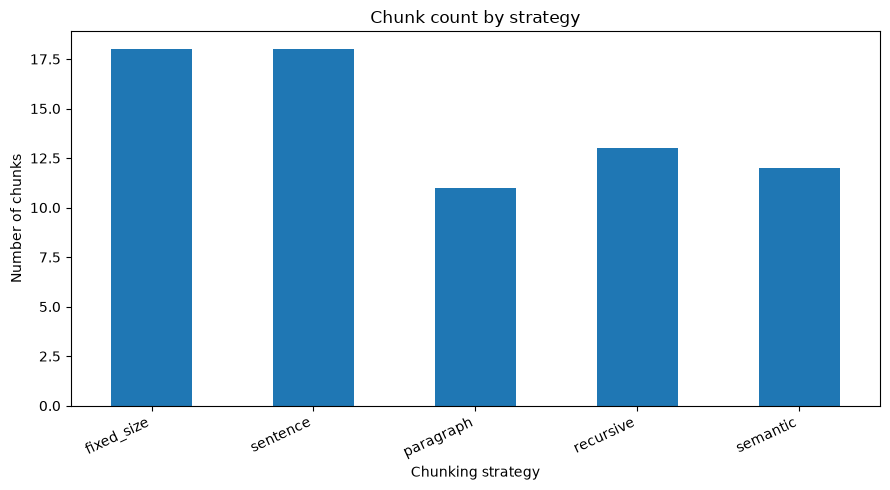

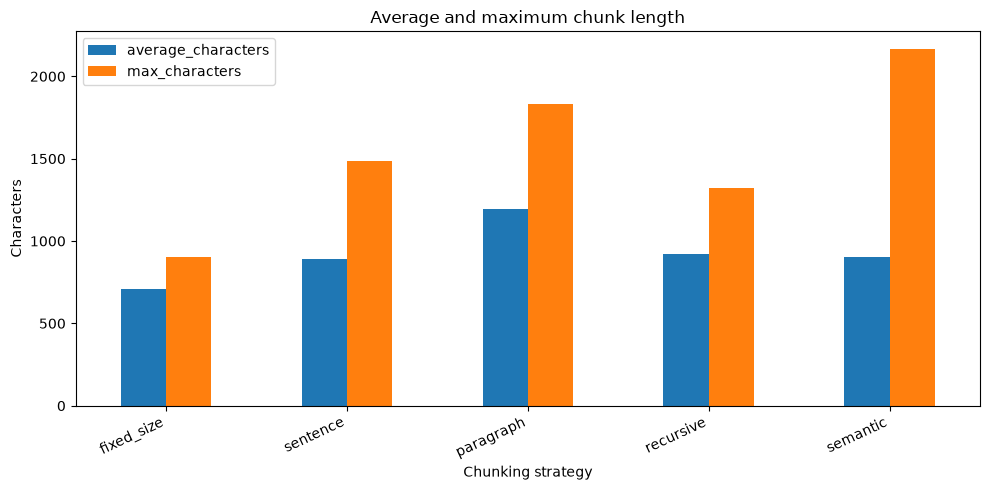

In [17]:
summary_rows = []

for strategy, chunks in chunks_by_strategy.items():
    lengths = [len(chunk.text) for chunk in chunks]
    summary_rows.append({
        "strategy": strategy,
        "chunks": len(chunks),
        "average_characters": round(sum(lengths) / len(lengths), 1) if lengths else 0,
        "min_characters": min(lengths) if lengths else 0,
        "max_characters": max(lengths) if lengths else 0,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

ax = summary_df.plot(
    x="strategy",
    y="chunks",
    kind="bar",
    legend=False,
    figsize=(9, 5),
    title="Chunk count by strategy",
)
ax.set_xlabel("Chunking strategy")
ax.set_ylabel("Number of chunks")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

ax = summary_df.plot(
    x="strategy",
    y=["average_characters", "max_characters"],
    kind="bar",
    figsize=(10, 5),
    title="Average and maximum chunk length",
)
ax.set_xlabel("Chunking strategy")
ax.set_ylabel("Characters")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 6. Inspect examples and verify metadata

Inspecting actual chunks helps reveal whether task headings, bullet points, and policy explanations stay together. Metadata records the source PDF, page, strategy, and chunk index.


In [18]:
INSPECT_STRATEGY = "recursive"

for chunk in chunks_by_strategy[INSPECT_STRATEGY][:3]:
    print("=" * 90)
    print("ID:", chunk.chunk_id)
    print("METADATA:", json.dumps(chunk.metadata, ensure_ascii=False, indent=2))
    print("TEXT:\n", chunk.text[:1800])


ID: week7-wed-2026-09-17:recursive:0000:7562cbda0c
METADATA: {
  "source": "Week7_Wed_17_Sep.pdf",
  "document_id": "week7-wed-2026-09-17",
  "page": 1,
  "section": null,
  "chunk_index": 0,
  "chunking_strategy": "recursive",
  "char_count": 1153,
  "chunk_size_target": 1200,
  "overlap_chars": 150
}
TEXT:
 Status 
Name: Timothious Gill 
Designation : AI/ML Intern 
GitLink: Week 7: Wed 
Date: 17/09/2026 
Summary  
Today I continued working on Task 29, which focuses on building a FastAPI service for interacting 
with both local and hosted Large Language Models (LLMs). The main focus was on improving the 
service structure, separating configuration from application logic, using a shared model-calling 
function, integrating OpenAI-compatible clients, and making the service easier to configure and 
evaluate. 
A major part of today's work involved understanding the architecture of the FastAPI service. Both 
/chat/local and /chat/hosted endpoints follow the same request and response contra

## 7. Export chunks and summary files

JSONL is convenient for downstream vector indexing because each line contains one chunk and its metadata. The CSV is a compact strategy comparison.


In [19]:
output_jsonl = Path("pure_python_Week7_PDF_chunking_results.jsonl")

with output_jsonl.open("w", encoding="utf-8") as f:
    for strategy, chunks in chunks_by_strategy.items():
        for chunk in chunks:
            record = {
                "chunk_id": chunk.chunk_id,
                "strategy": strategy,
                "text": chunk.text,
                "metadata": chunk.metadata,
            }

            f.write(json.dumps(record, ensure_ascii=False) + "\n")

output_csv = Path("Week7_PDF_chunking_comparison.csv")
summary_df.to_csv(output_csv, index=False)

print("Saved:", output_jsonl.resolve())
print("Saved:", output_csv.resolve())


Saved: /home/as/Downloads/Repos/DailyTask/Task31/pure_python_Week7_PDF_chunking_results.jsonl
Saved: /home/as/Downloads/Repos/DailyTask/Task31/Week7_PDF_chunking_comparison.csv


## 8. Retrieval evaluation plan

Chunk counts alone cannot tell us which strategy answers questions best. Build a small labeled question set from this PDF, where each question maps to its expected page/section or relevant passage. Then evaluate all strategies using the same embedding model and retrieval configuration.

Suggested measures:

- **Recall@3:** Did at least one relevant chunk appear in the top three?
- **Precision@3:** What fraction of the top three retrieved chunks are relevant?
- **Citation/page accuracy:** Does the response cite the page that actually supports the answer?
- **Faithfulness:** Is the generated answer supported by retrieved text?
- **Latency and indexing cost:** How long does ingestion and retrieval take?

Do not report retrieval scores until a labeled question set and actual retrieval run have been completed.


## 9. Engineering recommendation

For this six-page task report, begin with **heading-aware recursive chunking**, preserving page number, task heading, source filename, and chunking strategy in metadata. Add a preprocessing step that identifies headings and task labels before chunking.

The current chunkers are educational baselines. The paragraph implementation now falls back to recursive splitting when an individual paragraph is too large. For production, switch character limits to tokenizer-aware token limits and handle tables/OCR explicitly.

Keep chunking entirely in the backend ingestion pipeline. At question time, retrieve relevant chunks and send only the evidence and useful source references to the LLM. The LLM does not need to know the splitter implementation, threshold, or chunking code.
